In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

for m in (np, pd, sklearn):
    print(f"{m.__name__:12s} {m.__version__}")

numpy        2.5.2
pandas       3.0.5
sklearn      1.9.0


In [2]:
ticker = "RELIANCE.NS"

df = yf.download(
    ticker,
    period="5y",
    interval="1d",
    auto_adjust=False
)

df.reset_index(inplace=True)

# Flatten MultiIndex columns (new yfinance format)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] for col in df.columns]

df.head()


[*********************100%***********************]  1 of 1 completed


,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-08-26,1010.210754,1029.352295,1036.020996,1017.607117,1018.991638,18589616
1,2021-08-27,1008.829346,1027.944702,1035.028809,1022.706726,1032.375122,10480636
2,2021-08-30,1028.236816,1047.719971,1050.304443,1032.282837,1038.374634,14027062
3,2021-08-31,1022.756714,1042.135864,1053.950195,1034.797974,1050.788940,26485463
4,2021-09-01,1026.810059,1046.266235,1058.172974,1044.374146,1048.989136,11145486


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   Date       1240 non-null   datetime64[s]
 1   Adj Close  1240 non-null   float64      
 2   Close      1240 non-null   float64      
 3   High       1240 non-null   float64      
 4   Low        1240 non-null   float64      
 5   Open       1240 non-null   float64      
 6   Volume     1240 non-null   int64        
dtypes: datetime64[s](1), float64(5), int64(1)
memory usage: 67.9 KB


## A1. Load and Describe the Series

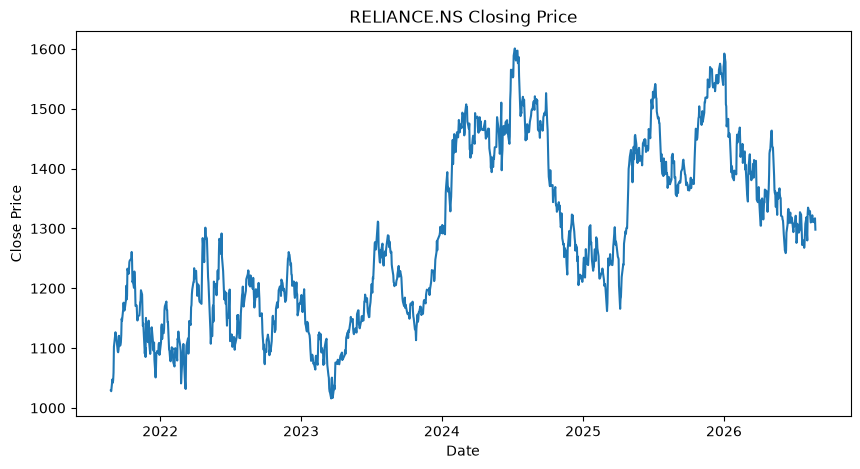

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Close"])

plt.title(f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

In [5]:
print("Ticker:", ticker)
print("Start Date:", df["Date"].min().date())
print("End Date:", df["Date"].max().date())
print("Trading Days:", len(df))

Ticker: RELIANCE.NS
Start Date: 2021-08-26
End Date: 2026-08-26
Trading Days: 1240


### Observation (A1)

- The dataset contains daily stock prices of RELIANCE.NS arranged in chronological order.
- It covers approximately five years of trading data with 1240 trading days.
- The row order is important because previous prices are used to predict future prices.
- Unlike the housing dataset, shuffling the rows would break the time sequence and produce incorrect results.

## A2. Lag Features

In [6]:
df["Close_lag1"] = df["Close"].shift(1)
df["Close_lag2"] = df["Close"].shift(2)
df["Close_lag3"] = df["Close"].shift(3)

df["RollingMean_5"] = df["Close"].rolling(5).mean()

df["Target"] = df["Close"].shift(-1)

In [7]:
df = df.dropna()

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Close_lag1,Close_lag2,Close_lag3,RollingMean_5,Target
4,2021-09-01,1026.810059,1046.266235,1058.172974,1044.374146,1048.989136,11145486,1042.135864,1047.719971,1027.944702,1038.683813,1058.865234
5,2021-09-02,1039.174805,1058.865234,1065.049316,1040.682129,1040.682129,9956770,1046.266235,1042.135864,1047.719971,1044.586401,1102.292358
6,2021-09-03,1081.794434,1102.292358,1105.292114,1062.603394,1066.064575,30664428,1058.865234,1046.266235,1042.135864,1059.455933,1119.414062
7,2021-09-06,1098.597778,1119.414062,1144.519653,1113.137573,1113.599121,33641710,1102.292358,1058.865234,1046.266235,1073.794751,1126.474976
8,2021-09-07,1105.527344,1126.474976,1134.366577,1113.137573,1121.444580,17349882,1119.414062,1102.292358,1058.865234,1090.662573,1122.067627


### Observation (A2)

- Lag features use the closing prices from previous trading days as input for prediction.
- The rolling mean provides a short-term average of recent prices.
- The first few rows contain missing values because previous days are unavailable for lag calculations.
- These rows are removed before training the model.

## A3. The Naive Baseline

In [8]:
y_true = df["Target"]

y_pred = df["Close"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 13.137752937594888
RMSE: 17.984027267529072


### Observation (A3)

- The naive baseline assumes that tomorrow's closing price will be the same as today's closing price.
- This provides a simple benchmark for evaluating prediction models.
- Any machine learning model should achieve lower prediction error than this baseline to be considered useful.

## B1. Random Split versus Chronological Split

In [9]:
features = [
    "Close_lag1",
    "Close_lag2",
    "Close_lag3",
    "RollingMean_5"
]

X = df[features]
y = df["Target"]

In [10]:
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)

random_model = RandomForestRegressor(random_state=RANDOM_STATE)

random_model.fit(X_train_random, y_train_random)

random_pred = random_model.predict(X_test_random)

random_mae = mean_absolute_error(y_test_random, random_pred)

In [11]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [12]:
chrono_model = RandomForestRegressor(random_state=RANDOM_STATE)

chrono_model.fit(X_train, y_train)

chrono_pred = chrono_model.predict(X_test)

chrono_mae = mean_absolute_error(y_test, chrono_pred)

In [13]:
comparison = pd.DataFrame({
    "Method": ["Random Split", "Chronological Split"],
    "Test MAE": [random_mae, chrono_mae]
})

comparison

,Method,Test MAE
0,Random Split,18.785589
1,Chronological Split,19.512040


### Observation (B1)

- The random split produced a slightly lower MAE than the chronological split.
- Randomly shuffling time-series data mixes past and future observations, causing data leakage.
- In practice, future stock prices are unknown during training, so chronological splitting provides a more realistic evaluation.
- Therefore, the chronological split should be preferred for time-series prediction tasks.

## C1. Would You Trade on It?

In [14]:
actual_direction = (y_test.values > X_test["Close_lag1"].values)

predicted_direction = (chrono_pred > X_test["Close_lag1"].values)

direction_accuracy = np.mean(actual_direction == predicted_direction)

print("Directional Accuracy:", direction_accuracy)

Directional Accuracy: 0.562753036437247


### Observation (C1)

- Directional accuracy measures how often the model correctly predicts whether the stock price will increase or decrease.
- The model achieved a directional accuracy of approximately **56.28%**, which is only slightly better than random guessing.
- Although the prediction error is reasonably low, the model is not accurate enough for reliable trading decisions.
- Additional features and more advanced models would be required before using it in real trading.